In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Intel Image Classification — CNN vs Transfer Learning

## Objective

The goal of this project is to classify natural scene images into six categories:

- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street

We will first establish a baseline using a simple CNN and then compare its performance with a pretrained ResNet18 model using transfer learning.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [4]:
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cpu
GPU available: False


In [8]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/puneet6060
/kaggle/input/datasets/puneet6060/intel-image-classification
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/street
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/buildings
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/sea
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/forest
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/glacier
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred
/kaggle/input/datasets/puneet6060/in

In [9]:
DATA_DIR = "/kaggle/input/datasets/puneet6060/intel-image-classification"

TRAIN_DIR = os.path.join(DATA_DIR, "seg_train", "seg_train")
TEST_DIR = os.path.join(DATA_DIR, "seg_test", "seg_test")

print("Training directory:", TRAIN_DIR)
print("Testing directory:", TEST_DIR)

Training directory: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Testing directory: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test


In [10]:
print("Training classes:")
print(os.listdir(TRAIN_DIR))

print("\nTesting classes:")
print(os.listdir(TEST_DIR))

Training classes:
['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']

Testing classes:
['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [11]:
classes = sorted(os.listdir(TRAIN_DIR))

train_counts = {}

for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)
    train_counts[class_name] = len(os.listdir(class_path))

print("Training images per class:")

for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

Training images per class:
buildings: 2191
forest: 2271
glacier: 2404
mountain: 2512
sea: 2274
street: 2382


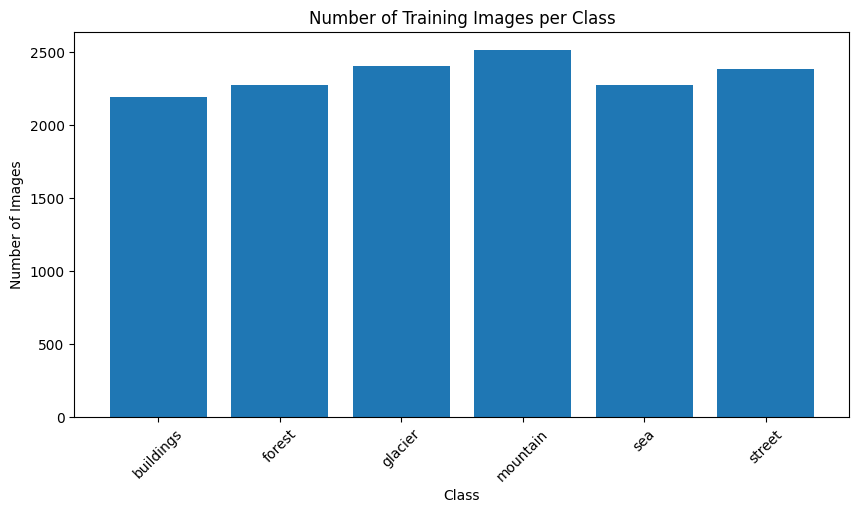

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(train_counts.keys(), train_counts.values())

plt.title("Number of Training Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

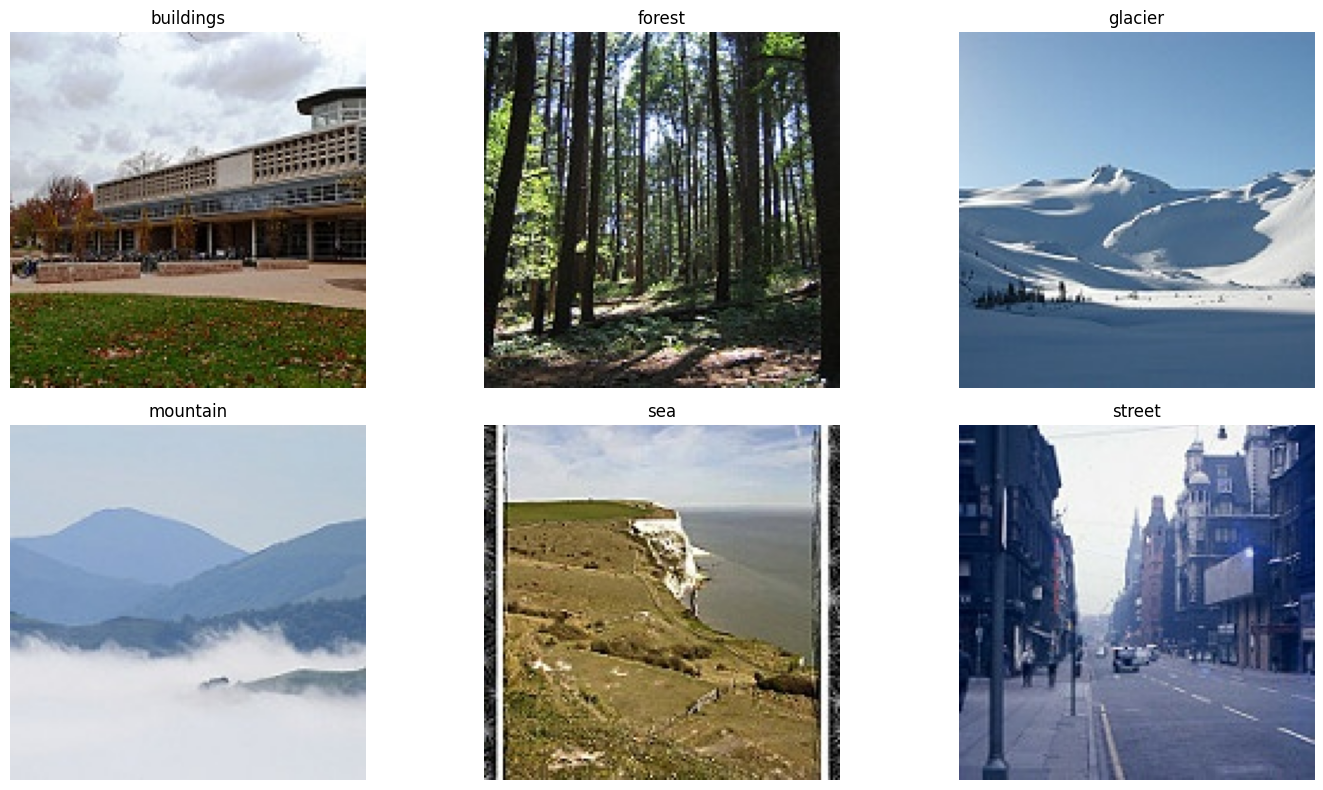

In [13]:
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):
    
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
image_sizes = []

for class_name in classes:
    
    class_path = os.path.join(TRAIN_DIR, class_name)
    
    for image_name in os.listdir(class_path)[:100]:
        
        image_path = os.path.join(class_path, image_name)
        
        try:
            image = Image.open(image_path)
            image_sizes.append(image.size)
        except:
            pass

print("First 10 image sizes:")
print(image_sizes[:10])

First 10 image sizes:
[(150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150)]


In [15]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Average width: 150.0
Average height: 149.87166666666667


In [18]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

print("Classes:", train_dataset.classes)
print("Number of training images:", len(train_dataset))
print("Number of testing images:", len(test_dataset))

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of training images: 14034
Number of testing images: 3000


In [20]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 439
Testing batches: 94


In [21]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [22]:
class SimpleCNN(nn.Module):
    
    def __init__(self, num_classes=6):
        super().__init__()
        
        self.features = nn.Sequential(
            
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            
            nn.Dropout(0.5),
            
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

cnn_model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

Using device: cpu


In [39]:
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    
    model.train()
    
    for epoch in range(epochs):
        
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            loss.backward()
            
            optimizer.step()
            
            running_loss += loss.item()
            
            predictions = torch.argmax(outputs, dim=1)
            
            total += labels.size(0)
            correct += (predictions == labels).sum().item()
        
        accuracy = correct / total
        
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {running_loss/len(train_loader):.4f} "
            f"Accuracy: {accuracy:.4f}"
        )

In [ ]:
train_model(
    cnn_model,
    train_loader,
    criterion,
    optimizer,
    epochs=10
)

Epoch [1/10] Loss: 1.0573 Accuracy: 0.6009
Epoch [2/10] Loss: 0.7062 Accuracy: 0.7462
Epoch [3/10] Loss: 0.5948 Accuracy: 0.7845
Epoch [4/10] Loss: 0.5301 Accuracy: 0.8105


In [ ]:
def evaluate_model(model, loader):
    
    model.eval()
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        
        for images, labels in loader:
            
            images = images.to(device)
            
            outputs = model(images)
            
            predictions = torch.argmax(
                outputs,
                dim=1
            ).cpu().numpy()
            
            all_predictions.extend(predictions)
            all_labels.extend(labels.numpy())
    
    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )
    
    return accuracy, all_labels, all_predictions

In [ ]:
cnn_accuracy, cnn_labels, cnn_predictions = evaluate_model(
    cnn_model,
    test_loader
)

print("CNN Test Accuracy:", cnn_accuracy)
print(
    classification_report(
        cnn_labels,
        cnn_predictions,
        target_names=train_dataset.classes
    )
)


In [ ]:
cm = confusion_matrix(
    cnn_labels,
    cnn_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

In [ ]:
weights = models.ResNet18_Weights.DEFAULT

resnet_model = models.resnet18(
    weights=weights
)

print(resnet_model)

In [ ]:
num_features = resnet_model.fc.in_features

resnet_model.fc = nn.Linear(
    num_features,
    6
)

resnet_model = resnet_model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)

In [ ]:
train_model(
    resnet_model,
    train_loader,
    criterion,
    optimizer,
    epochs=5
)

In [ ]:
resnet_accuracy, resnet_labels, resnet_predictions = evaluate_model(
    resnet_model,
    test_loader
)

print("ResNet18 Test Accuracy:", resnet_accuracy)

print(
    classification_report(
        resnet_labels,
        resnet_predictions,
        target_names=train_dataset.classes
    )
)

cm_resnet = confusion_matrix(
    resnet_labels,
    resnet_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet18 Confusion Matrix")

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Simple CNN",
        "ResNet18 Transfer Learning"
    ],
    
    "Test Accuracy": [
        cnn_accuracy,
        resnet_accuracy
    ]
})

comparison

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("CNN vs ResNet18")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()

In [ ]:
wrong_images = []
wrong_labels = []
wrong_predictions = []

resnet_model.eval()

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images_device = images.to(device)
        
        outputs = resnet_model(images_device)
        
        predictions = torch.argmax(
            outputs,
            dim=1
        ).cpu()
        
        for i in range(len(labels)):
            
            if predictions[i] != labels[i]:
                
                wrong_images.append(images[i])
                wrong_labels.append(labels[i].item())
                wrong_predictions.append(predictions[i].item())
                
                if len(wrong_images) == 9:
                    break
        
        if len(wrong_images) == 9:
            break

In [ ]:
plt.figure(figsize=(12, 12))

for i in range(len(wrong_images)):
    
    image = wrong_images[i].permute(1, 2, 0)
    
    image = image * torch.tensor(
        [0.229, 0.224, 0.225]
    ) + torch.tensor(
        [0.485, 0.456, 0.406]
    )
    
    image = torch.clamp(image, 0, 1)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    
    plt.title(
        f"Actual: {train_dataset.classes[wrong_labels[i]]}\n"
        f"Predicted: {train_dataset.classes[wrong_predictions[i]]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

# Conclusion

This project compared two approaches for natural scene image classification.

The first approach used a custom CNN trained from scratch. This provided a baseline and demonstrated how convolutional neural networks can learn visual features directly from images.

The second approach used ResNet18 with transfer learning. Instead of learning all visual features from the beginning, the model reused representations learned from a large-scale image dataset and adapted them to our six-class classification problem.

The comparison demonstrates the practical value of transfer learning for computer vision tasks.

The remaining classification errors were mainly associated with visually similar scene categories.

## Future Improvements

- Fine-tune more ResNet layers
- Experiment with stronger data augmentation
- Tune the learning rate and batch size
- Train for more epochs
- Compare additional pretrained architectures
- Perform more detailed error analysis